In [1]:
import json
import re
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import chi2

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [2]:
V1_BENCHMARK = "../benchmark/ClimateTwinBench_Hypothesis.json"
V2_BENCHMARK = "../benchmark/ClimateTwinBench_Hypothesis_V2.json"

ANSWER_FILES = {

    "ChatGPT_V1":"../evaluation/chatgpt_hypothesis_answers.txt",
    "ChatGPT_V2":"../evaluation/chatgpt_hypothesis_v2.txt",

    "Claude_V1":"../evaluation/claude_hypothesis_answers.txt",
    "Claude_V2":"../evaluation/claude_hypothesis_v2.txt",

    "DeepSeek_V1":"../evaluation/deepseek_hypothesis_answers.txt",
    "DeepSeek_V2":"../evaluation/deepseek_hypothesis_v2.txt",

    "Gemini_V1":"../evaluation/gemini_hypothesis_answers.txt",
    "Gemini_V2":"../evaluation/gemini_hypothesis_v2.txt"

}

In [3]:
with open(V1_BENCHMARK,"r",encoding="utf8") as f:
    benchmark_v1=json.load(f)

with open(V2_BENCHMARK,"r",encoding="utf8") as f:
    benchmark_v2=json.load(f)

print("V1 Questions:",len(benchmark_v1["questions"]))
print("V2 Questions:",len(benchmark_v2["questions"]))

V1 Questions: 240
V2 Questions: 240


In [4]:
def load_answers(filename):

    answers={}

    pattern=re.compile(r"(HYP-\d+).*?([ABC])$")

    with open(filename,"r",encoding="utf8") as f:

        for line in f:

            line=line.strip()

            m=pattern.search(line)

            if m:

                answers[m.group(1)]=m.group(2)

    return answers

In [10]:
predictions={}

for model,file in ANSWER_FILES.items():

    predictions[model]=load_answers(file)

    print(model,len(predictions[model]))

ChatGPT_V1 240
ChatGPT_V2 240
Claude_V1 240
Claude_V2 240
DeepSeek_V1 240
DeepSeek_V2 240
Gemini_V1 240
Gemini_V2 239


In [11]:
rows=[]

for q in benchmark_v2["questions"]:

    rows.append({

        "id":q["id"],

        "answer":q["answer"],

        "subcategory":q["subcategory"],

        "difficulty":q["difficulty"]

    })

master=pd.DataFrame(rows)

master.head()

,id,answer,subcategory,difficulty
0,HYP-001,C,persistent_regional_anomaly_verification,medium
1,HYP-002,A,persistent_regional_anomaly_verification,medium
2,HYP-003,B,persistent_regional_anomaly_verification,medium
3,HYP-004,C,persistent_regional_anomaly_verification,medium
4,HYP-005,C,persistent_regional_anomaly_verification,medium


In [12]:
for model in predictions:

    master[model]=master["id"].map(predictions[model])

In [13]:
for model in predictions:

    master[model+"_correct"]=(

        master[model]==master["answer"]

    )

In [14]:
master.head()

,id,answer,subcategory,difficulty,ChatGPT_V1,ChatGPT_V2,Claude_V1,Claude_V2,DeepSeek_V1,DeepSeek_V2,Gemini_V1,Gemini_V2,ChatGPT_V1_correct,ChatGPT_V2_correct,Claude_V1_correct,Claude_V2_correct,DeepSeek_V1_correct,DeepSeek_V2_correct,Gemini_V1_correct,Gemini_V2_correct
0,HYP-001,C,persistent_regional_anomaly_verification,medium,C,C,C,C,C,C,A,C,True,True,True,True,True,True,False,True
1,HYP-002,A,persistent_regional_anomaly_verification,medium,A,A,A,A,A,A,B,A,True,True,True,True,True,True,False,True
2,HYP-003,B,persistent_regional_anomaly_verification,medium,B,B,B,B,B,B,C,B,True,True,True,True,True,True,False,True
3,HYP-004,C,persistent_regional_anomaly_verification,medium,C,C,C,C,C,C,A,C,True,True,True,True,True,True,False,True
4,HYP-005,C,persistent_regional_anomaly_verification,medium,C,C,C,C,C,C,B,C,True,True,True,True,True,True,False,True


In [15]:
overall=[]

for model in predictions:

    acc=master[model+"_correct"].mean()*100

    overall.append({

        "Model":model,

        "Accuracy":round(acc,2)

    })

overall=pd.DataFrame(overall)

overall=overall.sort_values("Accuracy",ascending=False)

overall

,Model,Accuracy
2,Claude_V1,100.00
4,DeepSeek_V1,100.00
5,DeepSeek_V2,98.75
3,Claude_V2,96.25
1,ChatGPT_V2,90.00
0,ChatGPT_V1,64.17
7,Gemini_V2,45.42
6,Gemini_V1,32.50


In [16]:
overall.to_csv(

    "../results/analysis_overall_accuracy.csv",

    index=False

)

In [17]:
records=[]

for model in predictions:

    for cat in master["subcategory"].unique():

        temp=master[master["subcategory"]==cat]

        acc=temp[model+"_correct"].mean()*100

        records.append({

            "Model":model,

            "Category":cat,

            "Accuracy":round(acc,2)

        })

category_results=pd.DataFrame(records)

category_results.head()

,Model,Category,Accuracy
0,ChatGPT_V1,persistent_regional_anomaly_verification,90.0
1,ChatGPT_V1,localized_intensification_verification,77.5
2,ChatGPT_V1,wet_anomaly_consistency_verification,100.0
3,ChatGPT_V1,compound_state_transition_verification,45.0
4,ChatGPT_V1,spatial_coherence_verification,37.5


In [18]:
category_results.to_csv(

    "../results/analysis_category_accuracy.csv",

    index=False

)

In [19]:
pivot=category_results.pivot(

    index="Category",

    columns="Model",

    values="Accuracy"

)

pivot

Model,ChatGPT_V1,ChatGPT_V2,Claude_V1,Claude_V2,DeepSeek_V1,DeepSeek_V2,Gemini_V1,Gemini_V2
Category,,,,,,,,
compound_state_transition_verification,45.0,40.0,100.0,77.5,100.0,100.0,35.0,37.5
localized_intensification_verification,77.5,100.0,100.0,100.0,100.0,97.5,27.5,27.5
persistent_regional_anomaly_verification,90.0,100.0,100.0,100.0,100.0,100.0,22.5,100.0
reliability_aware_claim_verification,35.0,100.0,100.0,100.0,100.0,95.0,27.5,47.5
spatial_coherence_verification,37.5,100.0,100.0,100.0,100.0,100.0,37.5,32.5
wet_anomaly_consistency_verification,100.0,100.0,100.0,100.0,100.0,100.0,45.0,27.5


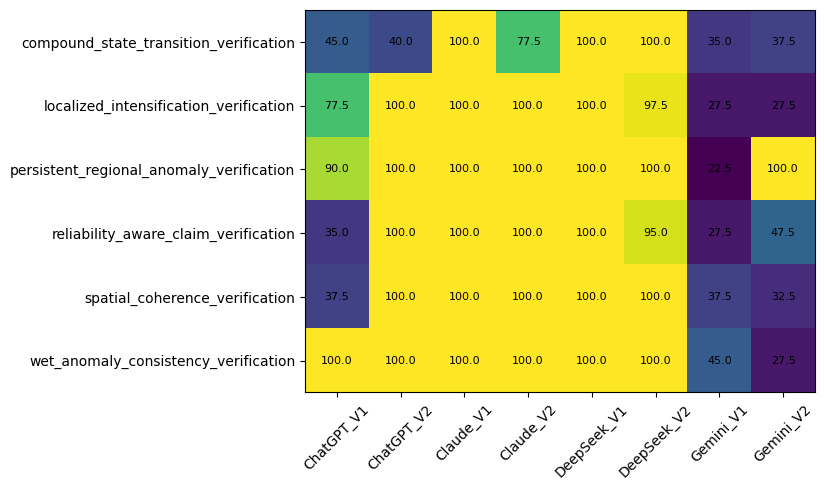

In [20]:
fig,ax=plt.subplots(figsize=(11,5))

im=ax.imshow(pivot.values)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns,rotation=45)

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):

        ax.text(

            j,

            i,

            f"{pivot.values[i,j]:.1f}",

            ha="center",

            va="center",

            fontsize=8

        )

plt.tight_layout()

plt.savefig(

    "../results/category_heatmap.png",

    dpi=300

)

plt.show()

In [21]:
transition_tables={}

In [22]:
for model in ["ChatGPT","Claude","DeepSeek"]:

    v1=master[model+"_V1_correct"]
    v2=master[model+"_V2_correct"]

    cc=((v1==True)&(v2==True)).sum()
    cw=((v1==True)&(v2==False)).sum()
    wc=((v1==False)&(v2==True)).sum()
    ww=((v1==False)&(v2==False)).sum()

    table=pd.DataFrame(

        [

            [cc,cw],

            [wc,ww]

        ],

        index=["Correct in V1","Wrong in V1"],

        columns=["Correct in V2","Wrong in V2"]

    )

    transition_tables[model]=table

    print("\n",model)

    display(table)


 ChatGPT


,Correct in V2,Wrong in V2
Correct in V1,142,12
Wrong in V1,74,12



 Claude


,Correct in V2,Wrong in V2
Correct in V1,231,9
Wrong in V1,0,0



 DeepSeek


,Correct in V2,Wrong in V2
Correct in V1,237,3
Wrong in V1,0,0


In [23]:
records=[]

for model in ["ChatGPT","Claude","DeepSeek"]:

    v1=master[model+"_V1_correct"]
    v2=master[model+"_V2_correct"]

    cc=((v1)&(v2)).sum()
    cw=((v1)&(~v2)).sum()
    wc=((~v1)&(v2)).sum()
    ww=((~v1)&(~v2)).sum()

    total=len(master)

    records.append({

        "Model":model,

        "Correct→Correct":cc,

        "Correct→Wrong":cw,

        "Wrong→Correct":wc,

        "Wrong→Wrong":ww,

        "Flip Rate %":round((cw+wc)/total*100,2)

    })

transition_summary=pd.DataFrame(records)

transition_summary

,Model,Correct→Correct,Correct→Wrong,Wrong→Correct,Wrong→Wrong,Flip Rate %
0,ChatGPT,142,12,74,12,35.83
1,Claude,231,9,0,0,3.75
2,DeepSeek,237,3,0,0,1.25


In [24]:
transition_summary.to_csv(

    "../results/v1_v2_transition_summary.csv",

    index=False

)

In [25]:
for model in ["ChatGPT","Claude","DeepSeek"]:

    print("="*60)

    print(model)

    temp=master[

        (master[model+"_V1_correct"])

        &

        (~master[model+"_V2_correct"])

    ]

    print(temp[["id","subcategory","difficulty"]])

ChatGPT
          id                             subcategory difficulty
121  HYP-122  compound_state_transition_verification     medium
122  HYP-123  compound_state_transition_verification     medium
126  HYP-127  compound_state_transition_verification     medium
127  HYP-128  compound_state_transition_verification     medium
133  HYP-134  compound_state_transition_verification     medium
138  HYP-139  compound_state_transition_verification     medium
140  HYP-141  compound_state_transition_verification     medium
145  HYP-146  compound_state_transition_verification     medium
151  HYP-152  compound_state_transition_verification       hard
155  HYP-156  compound_state_transition_verification       hard
156  HYP-157  compound_state_transition_verification       hard
158  HYP-159  compound_state_transition_verification       hard
Claude
          id                             subcategory difficulty
133  HYP-134  compound_state_transition_verification     medium
134  HYP-135  compound_st

In [26]:
for model in ["ChatGPT","Claude","DeepSeek"]:

    print("="*60)

    print(model)

    temp=master[

        (~master[model+"_V1_correct"])

        &

        (master[model+"_V2_correct"])

    ]

    print(temp[["id","subcategory","difficulty"]])

ChatGPT
          id                               subcategory difficulty
32   HYP-033  persistent_regional_anomaly_verification       hard
34   HYP-035  persistent_regional_anomaly_verification       hard
36   HYP-037  persistent_regional_anomaly_verification       hard
38   HYP-039  persistent_regional_anomaly_verification       hard
44   HYP-045    localized_intensification_verification       hard
45   HYP-046    localized_intensification_verification       hard
46   HYP-047    localized_intensification_verification       hard
49   HYP-050    localized_intensification_verification       hard
51   HYP-052    localized_intensification_verification       hard
53   HYP-054    localized_intensification_verification       hard
55   HYP-056    localized_intensification_verification       hard
58   HYP-059    localized_intensification_verification       hard
59   HYP-060    localized_intensification_verification       hard
125  HYP-126    compound_state_transition_verification     medium
13

In [27]:
interesting=[]

for _,row in master.iterrows():

    drop=True

    for model in ["ChatGPT","Claude","DeepSeek"]:

        if not (

            row[model+"_V1_correct"]

            and

            (not row[model+"_V2_correct"])

        ):

            drop=False

            break

    if drop:

        interesting.append(row["id"])

interesting

[]

In [28]:
interesting=[]

for _,row in master.iterrows():

    improve=True

    for model in ["ChatGPT","Claude","DeepSeek"]:

        if not (

            (not row[model+"_V1_correct"])

            and

            row[model+"_V2_correct"]

        ):

            improve=False

            break

    if improve:

        interesting.append(row["id"])

interesting

[]

In [29]:
operation_map = {
    "persistent_regional_anomaly_verification":"Minimum Selection",
    "localized_intensification_verification":"Subtraction",
    "wet_anomaly_consistency_verification":"Fraction / Division",
    "compound_state_transition_verification":"Grid Averaging",
    "spatial_coherence_verification":"Graph Traversal",
    "reliability_aware_claim_verification":"Logical Thresholding"
}

master["operation"] = master["subcategory"].map(operation_map)

In [30]:
operation_results=[]

for model in ["ChatGPT","Claude","DeepSeek","Gemini"]:

    for version in ["V1","V2"]:

        col=f"{model}_{version}_correct"

        for op in master["operation"].unique():

            subset=master[master.operation==op]

            acc=100*subset[col].mean()

            operation_results.append({

                "Model":model,

                "Version":version,

                "Operation":op,

                "Accuracy":round(acc,2)

            })

operation_df=pd.DataFrame(operation_results)

operation_df.head()

,Model,Version,Operation,Accuracy
0,ChatGPT,V1,Minimum Selection,90.0
1,ChatGPT,V1,Subtraction,77.5
2,ChatGPT,V1,Fraction / Division,100.0
3,ChatGPT,V1,Grid Averaging,45.0
4,ChatGPT,V1,Graph Traversal,37.5


In [31]:
pivot = operation_df.pivot_table(

    index="Operation",

    columns=["Model","Version"],

    values="Accuracy"

)

pivot

Model                ChatGPT        Claude        DeepSeek        Gemini  \
Version                   V1     V2     V1     V2       V1     V2     V1   
Operation                                                                  
Fraction / Division    100.0  100.0  100.0  100.0    100.0  100.0   45.0   
Graph Traversal         37.5  100.0  100.0  100.0    100.0  100.0   37.5   
Grid Averaging          45.0   40.0  100.0   77.5    100.0  100.0   35.0   
Logical Thresholding    35.0  100.0  100.0  100.0    100.0   95.0   27.5   
Minimum Selection       90.0  100.0  100.0  100.0    100.0  100.0   22.5   
Subtraction             77.5  100.0  100.0  100.0    100.0   97.5   27.5   

Model                        
Version                  V2  
Operation                    
Fraction / Division    27.5  
Graph Traversal        32.5  
Grid Averaging         37.5  
Logical Thresholding   47.5  
Minimum Selection     100.0  
Subtraction            27.5

In [32]:
pivot.to_csv("../results/operation_accuracy.csv")

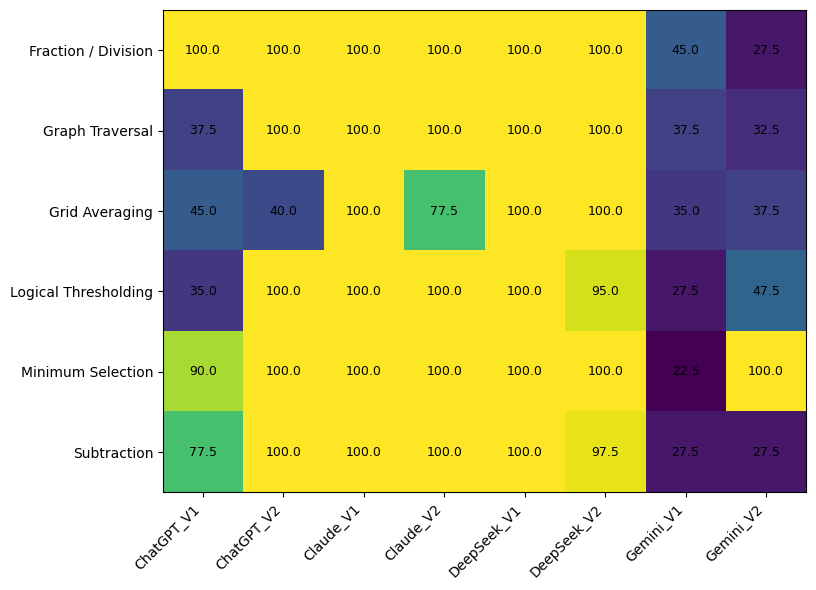

In [33]:
import matplotlib.pyplot as plt

fig,ax=plt.subplots(figsize=(12,6))

im=ax.imshow(pivot.values)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(
    [f"{a}_{b}" for a,b in pivot.columns],
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(
            j,
            i,
            f"{pivot.values[i,j]:.1f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.tight_layout()

plt.savefig("../results/operation_heatmap.png",dpi=300)

plt.show()

In [34]:
master["answer"].value_counts()

answer
B    86
C    79
A    75
Name: count, dtype: int64

In [36]:
master.columns.tolist()

['id',
 'answer',
 'subcategory',
 'difficulty',
 'ChatGPT_V1',
 'ChatGPT_V2',
 'Claude_V1',
 'Claude_V2',
 'DeepSeek_V1',
 'DeepSeek_V2',
 'Gemini_V1',
 'Gemini_V2',
 'ChatGPT_V1_correct',
 'ChatGPT_V2_correct',
 'Claude_V1_correct',
 'Claude_V2_correct',
 'DeepSeek_V1_correct',
 'DeepSeek_V2_correct',
 'Gemini_V1_correct',
 'Gemini_V2_correct',
 'operation']

In [37]:
master["Decision"] = master["answer"].map({
    "A": "REFUTED",
    "B": "INSUFFICIENT",
    "C": "SUPPORTED"
})

master["Decision"].value_counts()

Decision
INSUFFICIENT    86
SUPPORTED       79
REFUTED         75
Name: count, dtype: int64

In [38]:
master.to_csv("../results/master_analysis.csv", index=False)

In [39]:
decision_results=[]

for model in ["ChatGPT","Claude","DeepSeek","Gemini"]:

    for version in ["V1","V2"]:

        col=f"{model}_{version}_correct"

        for decision in master["Decision"].unique():

            subset=master[master.Decision==decision]

            acc=100*subset[col].mean()

            decision_results.append({

                "Model":model,

                "Version":version,

                "Decision":decision,

                "Accuracy":round(acc,2)

            })

decision_df=pd.DataFrame(decision_results)

decision_df.head()

,Model,Version,Decision,Accuracy
0,ChatGPT,V1,SUPPORTED,64.56
1,ChatGPT,V1,REFUTED,64.00
2,ChatGPT,V1,INSUFFICIENT,63.95
3,ChatGPT,V2,SUPPORTED,89.87
4,ChatGPT,V2,REFUTED,90.67


In [40]:
decision_table=decision_df.pivot_table(

    index="Decision",

    columns=["Model","Version"],

    values="Accuracy"

)

decision_table

Model        ChatGPT        Claude         DeepSeek         Gemini       
Version           V1     V2     V1      V2       V1      V2     V1     V2
Decision                                                                 
INSUFFICIENT   63.95  89.53  100.0   96.51    100.0   96.51  31.40  52.33
REFUTED        64.00  90.67  100.0  100.00    100.0  100.00  33.33  42.67
SUPPORTED      64.56  89.87  100.0   92.41    100.0  100.00  32.91  40.51

In [41]:
decision_table.to_csv("../results/decision_accuracy.csv")

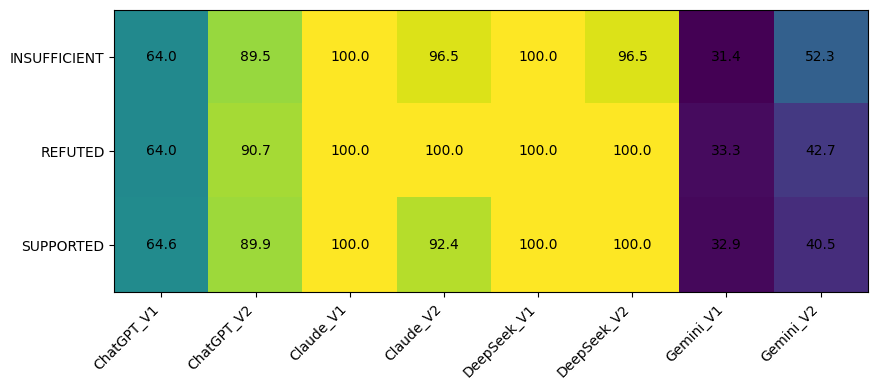

In [42]:
import matplotlib.pyplot as plt

fig,ax=plt.subplots(figsize=(11,4))

im=ax.imshow(decision_table.values)

ax.set_xticks(range(len(decision_table.columns)))
ax.set_xticklabels(

    [f"{a}_{b}" for a,b in decision_table.columns],

    rotation=45,

    ha="right"

)

ax.set_yticks(range(len(decision_table.index)))
ax.set_yticklabels(decision_table.index)

for i in range(decision_table.shape[0]):

    for j in range(decision_table.shape[1]):

        ax.text(

            j,

            i,

            f"{decision_table.values[i,j]:.1f}",

            ha="center",

            va="center",

            fontsize=10

        )

plt.tight_layout()

plt.savefig("../results/decision_heatmap.png",dpi=300)

plt.show()

In [43]:
difficulty_results=[]

for model in ["ChatGPT","Claude","DeepSeek","Gemini"]:

    for version in ["V1","V2"]:

        col=f"{model}_{version}_correct"

        for diff in master["difficulty"].unique():

            subset=master[master.difficulty==diff]

            acc=100*subset[col].mean()

            difficulty_results.append({

                "Model":model,

                "Version":version,

                "Difficulty":diff,

                "Accuracy":round(acc,2)

            })

difficulty_df=pd.DataFrame(difficulty_results)

In [44]:
difficulty_table=difficulty_df.pivot_table(

    index="Difficulty",

    columns=["Model","Version"],

    values="Accuracy"

)

difficulty_table

Model      ChatGPT        Claude         DeepSeek        Gemini       
Version         V1     V2     V1      V2       V1     V2     V1     V2
Difficulty                                                            
hard         58.09  94.12  100.0  100.00    100.0  98.53  29.41  36.03
medium       72.12  84.62  100.0   91.35    100.0  99.04  36.54  57.69

In [45]:
difficulty_table.to_csv("../results/difficulty_accuracy.csv")

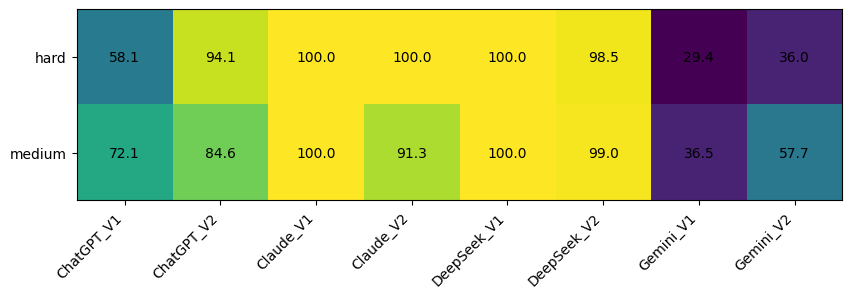

In [46]:
fig,ax=plt.subplots(figsize=(11,3))

im=ax.imshow(difficulty_table.values)

ax.set_xticks(range(len(difficulty_table.columns)))
ax.set_xticklabels(

    [f"{a}_{b}" for a,b in difficulty_table.columns],

    rotation=45,

    ha="right"

)

ax.set_yticks(range(len(difficulty_table.index)))
ax.set_yticklabels(difficulty_table.index)

for i in range(difficulty_table.shape[0]):

    for j in range(difficulty_table.shape[1]):

        ax.text(

            j,

            i,

            f"{difficulty_table.values[i,j]:.1f}",

            ha="center",

            va="center"

        )

plt.tight_layout()

plt.savefig("../results/difficulty_heatmap.png",dpi=300)

plt.show()

In [47]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 4.2 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.6 MB 4.3 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.6 MB 4.2 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.6 MB 3.2 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.6 MB 3.3 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 3.6 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.6 MB 3.6 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.6 MB 3.4 MB/s eta 0:00:02
   ---------------------------- ----------- 6.8/9.6 MB 3.5 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 3.5 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 3.5 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
from statsmodels.stats.contingency_tables import mcnemar

In [49]:
from statsmodels.stats.contingency_tables import mcnemar

results=[]

for model in ["ChatGPT","Claude","DeepSeek","Gemini"]:

    v1=master[f"{model}_V1_correct"]
    v2=master[f"{model}_V2_correct"]

    both_correct=((v1)&(v2)).sum()

    v1_only=((v1)&(~v2)).sum()

    v2_only=((~v1)&(v2)).sum()

    both_wrong=((~v1)&(~v2)).sum()

    table=[

        [both_correct,v1_only],

        [v2_only,both_wrong]

    ]

    test=mcnemar(table,exact=True)

    results.append({

        "Model":model,

        "V1 only":v1_only,

        "V2 only":v2_only,

        "p-value":test.pvalue

    })

mcnemar_df=pd.DataFrame(results)

mcnemar_df

,Model,V1 only,V2 only,p-value
0,ChatGPT,12,74,4.689760e-12
1,Claude,9,0,3.906250e-03
2,DeepSeek,3,0,2.500000e-01
3,Gemini,48,79,7.519595e-03


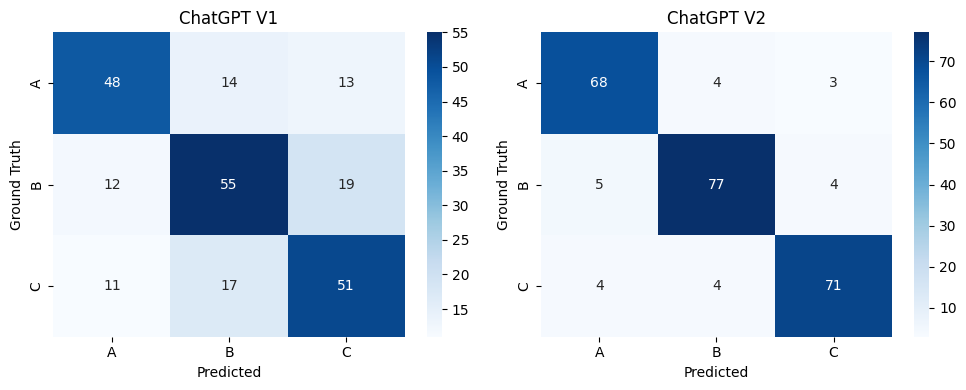

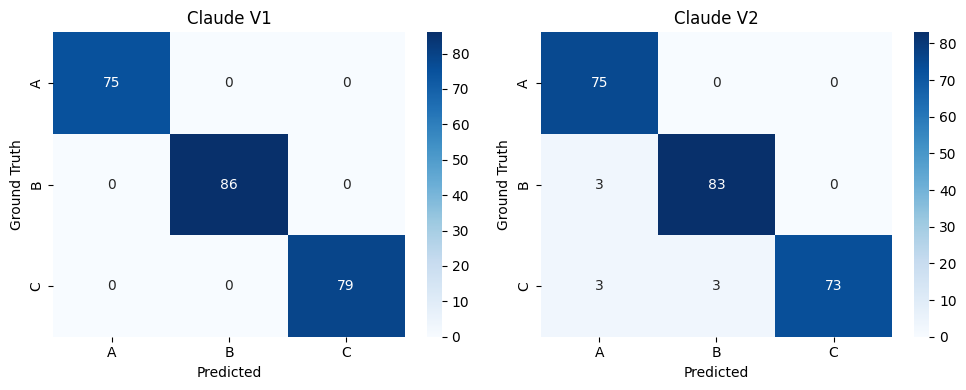

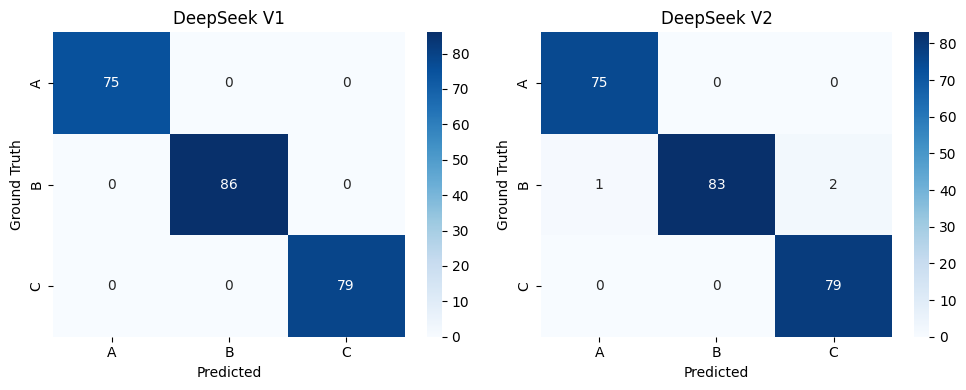

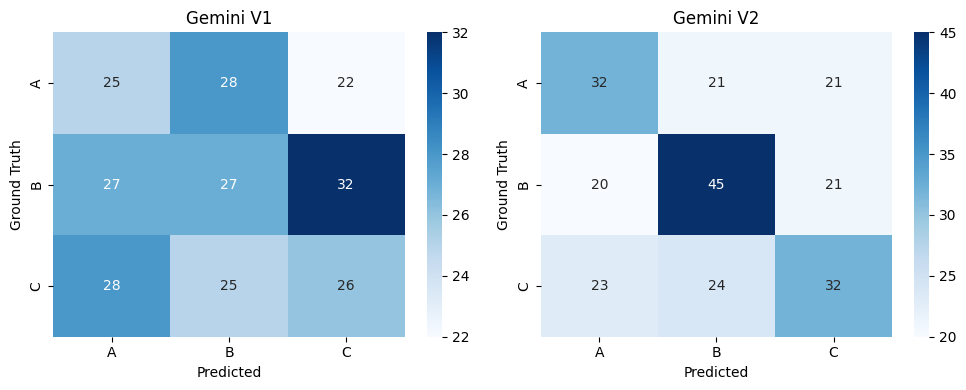

In [50]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels=["A","B","C"]

for model in ["ChatGPT","Claude","DeepSeek","Gemini"]:

    fig,axes=plt.subplots(1,2,figsize=(10,4))

    for i,version in enumerate(["V1","V2"]):

        pred=master[f"{model}_{version}"].fillna("")

        cm=confusion_matrix(master["answer"],pred,labels=labels)

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            ax=axes[i]
        )

        axes[i].set_title(f"{model} {version}")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Ground Truth")

    plt.tight_layout()
    plt.show()

In [51]:
records=[]

for model in ["ChatGPT","Claude","DeepSeek","Gemini"]:

    for cat in master["subcategory"].unique():

        subset=master[master.subcategory==cat]

        v1=subset[f"{model}_V1_correct"].mean()*100
        v2=subset[f"{model}_V2_correct"].mean()*100

        records.append({
            "Model":model,
            "Category":cat,
            "Improvement":v2-v1
        })

improve=pd.DataFrame(records)

display(improve.sort_values("Improvement",ascending=False))

,Model,Category,Improvement
18,Gemini,persistent_regional_anomaly_verification,77.5
5,ChatGPT,reliability_aware_claim_verification,65.0
4,ChatGPT,spatial_coherence_verification,62.5
1,ChatGPT,localized_intensification_verification,22.5
23,Gemini,reliability_aware_claim_verification,20.0
0,ChatGPT,persistent_regional_anomaly_verification,10.0
21,Gemini,compound_state_transition_verification,2.5
6,Claude,persistent_regional_anomaly_verification,0.0
14,DeepSeek,wet_anomaly_consistency_verification,0.0
19,Gemini,localized_intensification_verification,0.0


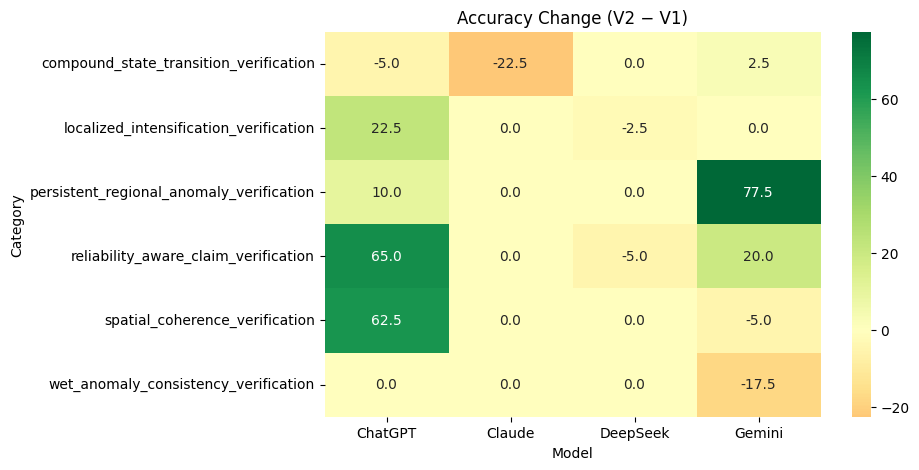

In [52]:
pivot=improve.pivot(
    index="Category",
    columns="Model",
    values="Improvement"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".1f"
)

plt.title("Accuracy Change (V2 − V1)")
plt.show()

In [53]:
models=[
"ChatGPT_V2_correct",
"Claude_V2_correct",
"DeepSeek_V2_correct",
"Gemini_V2_correct"
]

master["ModelsCorrect"]=master[models].sum(axis=1)

master["ModelsCorrect"].value_counts().sort_index()

ModelsCorrect
1      5
2     14
3    124
4     97
Name: count, dtype: int64

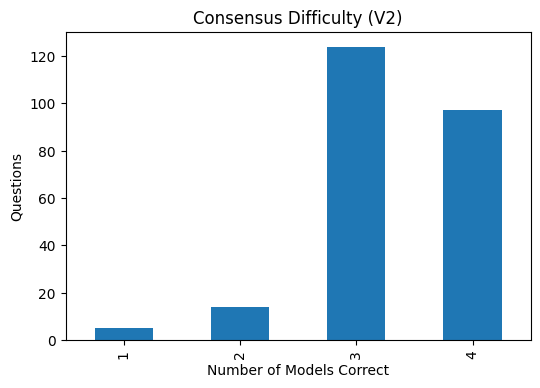

In [54]:
plt.figure(figsize=(6,4))

master["ModelsCorrect"].value_counts().sort_index().plot.bar()

plt.xlabel("Number of Models Correct")
plt.ylabel("Questions")
plt.title("Consensus Difficulty (V2)")
plt.show()

In [55]:
master["DifficultyIndex"]=master[models].mean(axis=1)

display(master[[
"id",
"subcategory",
"DifficultyIndex"
]].head())

,id,subcategory,DifficultyIndex
0,HYP-001,persistent_regional_anomaly_verification,1.0
1,HYP-002,persistent_regional_anomaly_verification,1.0
2,HYP-003,persistent_regional_anomaly_verification,1.0
3,HYP-004,persistent_regional_anomaly_verification,1.0
4,HYP-005,persistent_regional_anomaly_verification,1.0


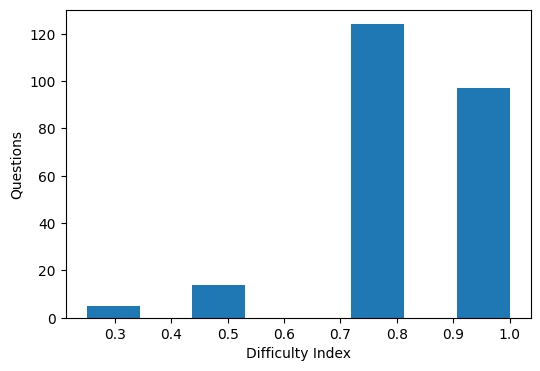

In [56]:
plt.figure(figsize=(6,4))

plt.hist(master["DifficultyIndex"],bins=8)

plt.xlabel("Difficulty Index")
plt.ylabel("Questions")

plt.show()

In [57]:
from itertools import combinations

models=[
"ChatGPT_V2",
"Claude_V2",
"DeepSeek_V2",
"Gemini_V2"
]

rows=[]

for a,b in combinations(models,2):

    agree=(master[a]==master[b]).mean()*100

    rows.append({
        "Model1":a,
        "Model2":b,
        "Agreement":agree
    })

agreement=pd.DataFrame(rows)

display(agreement)

,Model1,Model2,Agreement
0,ChatGPT_V2,Claude_V2,89.166667
1,ChatGPT_V2,DeepSeek_V2,88.750000
2,ChatGPT_V2,Gemini_V2,45.000000
3,Claude_V2,DeepSeek_V2,95.000000
4,Claude_V2,Gemini_V2,45.000000
5,DeepSeek_V2,Gemini_V2,45.416667


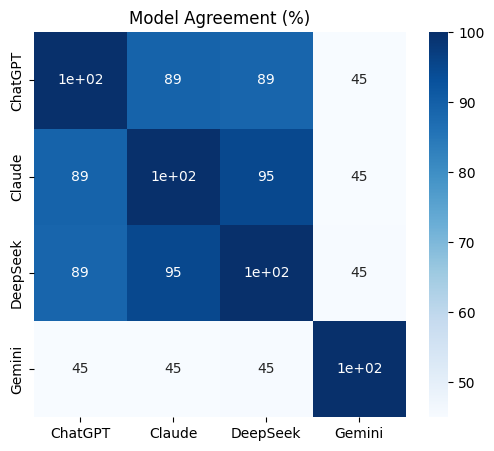

In [58]:
import numpy as np

names=["ChatGPT","Claude","DeepSeek","Gemini"]

mat=np.eye(4)*100

pairs=list(combinations(range(4),2))

for (i,j),(a,b) in zip(
pairs,
combinations(models,2)
):

    val=(master[a]==master[b]).mean()*100

    mat[i,j]=val
    mat[j,i]=val

plt.figure(figsize=(6,5))

sns.heatmap(
    mat,
    annot=True,
    xticklabels=names,
    yticklabels=names,
    cmap="Blues"
)

plt.title("Model Agreement (%)")
plt.show()

In [60]:
import numpy as np

def bootstrap(acc):

    scores=[]

    n=len(acc)

    for _ in range(5000):

        idx=np.random.choice(n,n,replace=True)

        scores.append(acc.iloc[idx].mean()*100)

    return np.percentile(scores,[2.5,97.5])

rows=[]

for col in [
"ChatGPT_V1_correct",
"ChatGPT_V2_correct",
"Claude_V1_correct",
"Claude_V2_correct",
"DeepSeek_V1_correct",
"DeepSeek_V2_correct",
"Gemini_V1_correct",
"Gemini_V2_correct"
]:

    low,high=bootstrap(master[col])

    rows.append({
        "Model":col,
        "Accuracy":master[col].mean()*100,
        "CI Low":low,
        "CI High":high
    })

ci=pd.DataFrame(rows)

display(ci)

,Model,Accuracy,CI Low,CI High
0,ChatGPT_V1_correct,64.166667,57.916667,70.416667
1,ChatGPT_V2_correct,90.000000,85.833333,93.750000
2,Claude_V1_correct,100.000000,100.000000,100.000000
3,Claude_V2_correct,96.250000,93.750000,98.333333
4,DeepSeek_V1_correct,100.000000,100.000000,100.000000
5,DeepSeek_V2_correct,98.750000,97.083333,100.000000
6,Gemini_V1_correct,32.500000,26.666667,38.333333
7,Gemini_V2_correct,45.416667,39.166667,52.083333


In [61]:
from scipy.stats import spearmanr

for model in ["ChatGPT","Claude","DeepSeek","Gemini"]:

    v1=[]
    v2=[]

    for cat in master.subcategory.unique():

        subset=master[master.subcategory==cat]

        v1.append(subset[f"{model}_V1_correct"].mean())
        v2.append(subset[f"{model}_V2_correct"].mean())

    rho,p=spearmanr(v1,v2)

    print(model)

    print("Spearman =",round(rho,3))

    print("p =",p)

    print()

ChatGPT
Spearman = 0.131
p = 0.8047261622231062

Claude
Spearman = nan
p = nan

DeepSeek
Spearman = nan
p = nan

Gemini
Spearman = -0.662
p = 0.1522570857927946



C:\Users\Aaditya\AppData\Local\Temp\ipykernel_25488\1805870538.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho,p=spearmanr(v1,v2)


In [63]:
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

rows=[]

models=[
"ChatGPT_V2",
"Claude_V2",
"DeepSeek_V2",
"Gemini_V2"
]

for a,b in combinations(models,2):

    temp=master[[a,b]].dropna()

    kappa=cohen_kappa_score(
        temp[a].astype(str),
        temp[b].astype(str)
    )

    rows.append({
        "Model1":a,
        "Model2":b,
        "Kappa":kappa
    })

kappa_df=pd.DataFrame(rows)

display(kappa_df.sort_values("Kappa",ascending=False))

,Model1,Model2,Kappa
3,Claude_V2,DeepSeek_V2,0.924986
0,ChatGPT_V2,Claude_V2,0.837326
1,ChatGPT_V2,DeepSeek_V2,0.831140
5,DeepSeek_V2,Gemini_V2,0.183056
2,ChatGPT_V2,Gemini_V2,0.176057
4,Claude_V2,Gemini_V2,0.175623


In [64]:
from itertools import combinations

rows=[]

models=[
"ChatGPT_V2_correct",
"Claude_V2_correct",
"DeepSeek_V2_correct",
"Gemini_V2_correct"
]

for a,b in combinations(models,2):

    overlap=((~master[a]) & (~master[b])).sum()

    rows.append({
        "Model1":a,
        "Model2":b,
        "Shared Errors":overlap
    })

overlap=pd.DataFrame(rows)

display(overlap)

,Model1,Model2,Shared Errors
0,ChatGPT_V2_correct,Claude_V2_correct,6
1,ChatGPT_V2_correct,DeepSeek_V2_correct,0
2,ChatGPT_V2_correct,Gemini_V2_correct,15
3,Claude_V2_correct,DeepSeek_V2_correct,0
4,Claude_V2_correct,Gemini_V2_correct,6
5,DeepSeek_V2_correct,Gemini_V2_correct,2


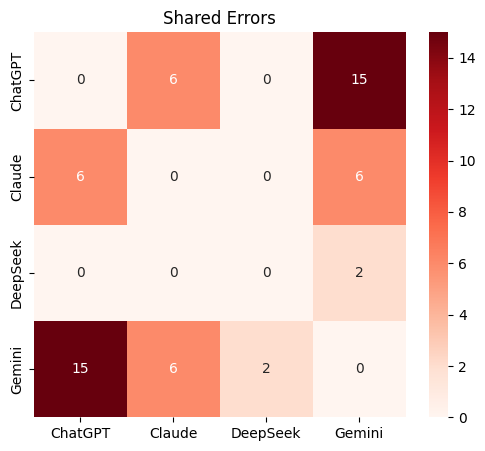

In [65]:
names=["ChatGPT","Claude","DeepSeek","Gemini"]

mat=np.zeros((4,4))

for i in range(4):
    mat[i,i]=0

pairs=list(combinations(range(4),2))

for (i,j),(a,b) in zip(
pairs,
combinations(models,2)
):

    val=((~master[a]) & (~master[b])).sum()

    mat[i,j]=val
    mat[j,i]=val

plt.figure(figsize=(6,5))

sns.heatmap(
    mat,
    annot=True,
    cmap="Reds",
    xticklabels=names,
    yticklabels=names
)

plt.title("Shared Errors")
plt.show()

In [66]:
correct_cols=[
"ChatGPT_V2_correct",
"Claude_V2_correct",
"DeepSeek_V2_correct",
"Gemini_V2_correct"
]

master["Oracle"]=master[correct_cols].any(axis=1)

oracle=master["Oracle"].mean()*100

print("Oracle Accuracy:",oracle)

Oracle Accuracy: 100.0


In [67]:
from collections import Counter

preds=[]

for _,row in master.iterrows():

    votes=[
        row["ChatGPT_V2"],
        row["Claude_V2"],
        row["DeepSeek_V2"],
        row["Gemini_V2"]
    ]

    votes=[v for v in votes if pd.notna(v)]

    pred=Counter(votes).most_common(1)[0][0]

    preds.append(pred)

master["Majority"]=preds

acc=(master["Majority"]==master["answer"]).mean()*100

print("Majority Vote Accuracy:",acc)

Majority Vote Accuracy: 95.41666666666667


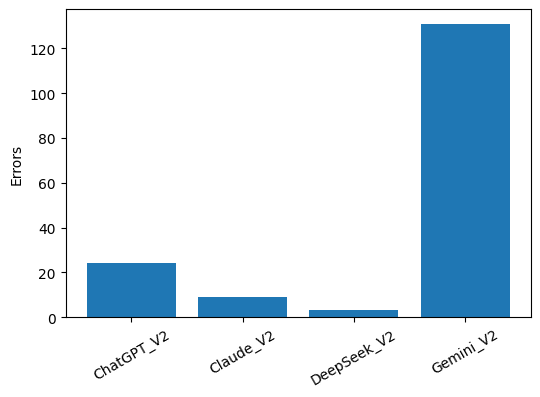

In [68]:
rows=[]

for model in [
"ChatGPT_V2",
"Claude_V2",
"DeepSeek_V2",
"Gemini_V2"
]:

    wrong=master[master[model]!=master.answer]

    rows.append({
        "Model":model,
        "Errors":len(wrong)
    })

err=pd.DataFrame(rows)

plt.figure(figsize=(6,4))

plt.bar(err.Model,err.Errors)

plt.ylabel("Errors")

plt.xticks(rotation=30)

plt.show()

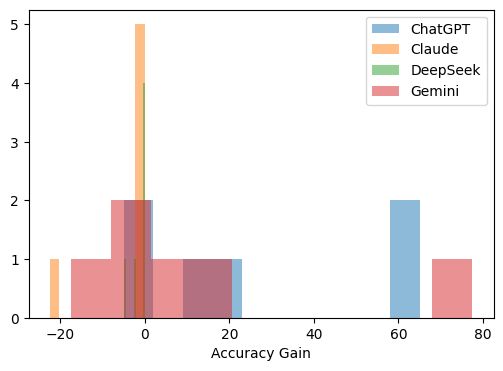

In [69]:
rows=[]

for model in ["ChatGPT","Claude","DeepSeek","Gemini"]:

    for cat in master.subcategory.unique():

        subset=master[master.subcategory==cat]

        gain=100*(
            subset[f"{model}_V2_correct"].mean()
            -
            subset[f"{model}_V1_correct"].mean()
        )

        rows.append({
            "Model":model,
            "Gain":gain
        })

gain_df=pd.DataFrame(rows)

plt.figure(figsize=(6,4))

for model in gain_df.Model.unique():

    plt.hist(
        gain_df[gain_df.Model==model]["Gain"],
        alpha=0.5,
        label=model
    )

plt.legend()

plt.xlabel("Accuracy Gain")

plt.show()

In [70]:
from statsmodels.stats.contingency_tables import mcnemar

rows=[]

for cat in master.subcategory.unique():

    subset=master[master.subcategory==cat]

    a=subset.ChatGPT_V1_correct
    b=subset.ChatGPT_V2_correct

    table=[
        [((a)&(b)).sum(),((a)&(~b)).sum()],
        [((~a)&(b)).sum(),((~a)&(~b)).sum()]
    ]

    p=mcnemar(table,exact=True).pvalue

    rows.append({
        "Category":cat,
        "p":p
    })

pd.DataFrame(rows)

,Category,p
0,persistent_regional_anomaly_verification,1.250000e-01
1,localized_intensification_verification,3.906250e-03
2,wet_anomaly_consistency_verification,1.000000e+00
3,compound_state_transition_verification,8.318119e-01
4,spatial_coherence_verification,5.960464e-08
5,reliability_aware_claim_verification,2.980232e-08


In [71]:
correct_cols=[
"ChatGPT_V2_correct",
"Claude_V2_correct",
"DeepSeek_V2_correct",
"Gemini_V2_correct"
]

master["ModelsCorrect"]=master[correct_cols].sum(axis=1)

display(
master["ModelsCorrect"].value_counts().sort_index()
)

ModelsCorrect
1      5
2     14
3    124
4     97
Name: count, dtype: int64

In [72]:
hardest=master[master.ModelsCorrect<=1]

display(
hardest[
[
"id",
"subcategory",
"difficulty",
"ModelsCorrect"
]
]
)

,id,subcategory,difficulty,ModelsCorrect
133,HYP-134,compound_state_transition_verification,medium,1
135,HYP-136,compound_state_transition_verification,medium,1
140,HYP-141,compound_state_transition_verification,medium,1
144,HYP-145,compound_state_transition_verification,medium,1
145,HYP-146,compound_state_transition_verification,medium,1


In [73]:
easy=master[master.ModelsCorrect==4]

print("Easy Questions:",len(easy))

Easy Questions: 97


,Category,Average Models Correct
0,persistent_regional_anomaly_verification,4.000
1,localized_intensification_verification,3.250
2,wet_anomaly_consistency_verification,3.275
3,compound_state_transition_verification,2.550
4,spatial_coherence_verification,3.325
5,reliability_aware_claim_verification,3.425


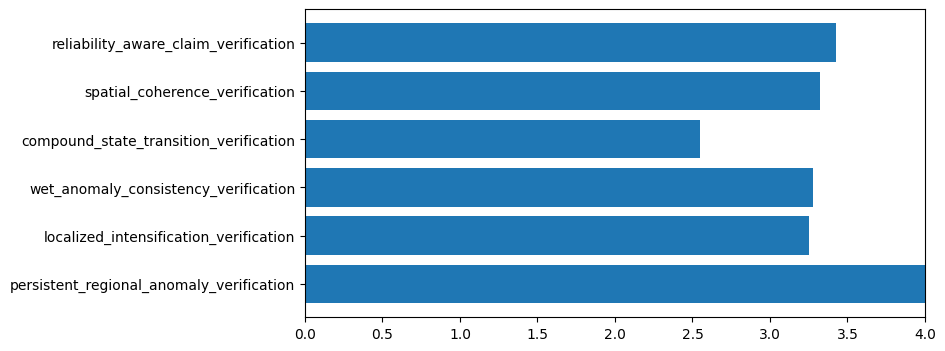

In [74]:
rows=[]

for cat in master.subcategory.unique():

    subset=master[master.subcategory==cat]

    rows.append({

        "Category":cat,

        "Average Models Correct":
        subset.ModelsCorrect.mean()

    })

cat_consensus=pd.DataFrame(rows)

display(cat_consensus)

plt.figure(figsize=(8,4))

plt.barh(
cat_consensus.Category,
cat_consensus["Average Models Correct"]
)

plt.xlim(0,4)

plt.show()

In [75]:
rows=[]

for diff in master.difficulty.unique():

    subset=master[master.difficulty==diff]

    rows.append({

        "Difficulty":diff,

        "Average Models Correct":
        subset.ModelsCorrect.mean()

    })

pd.DataFrame(rows)

,Difficulty,Average Models Correct
0,medium,3.326923
1,hard,3.286765


,Category,Disagreement
0,persistent_regional_anomaly_verification,0.000
1,localized_intensification_verification,0.750
2,wet_anomaly_consistency_verification,0.725
3,compound_state_transition_verification,1.450
4,spatial_coherence_verification,0.675
5,reliability_aware_claim_verification,0.575


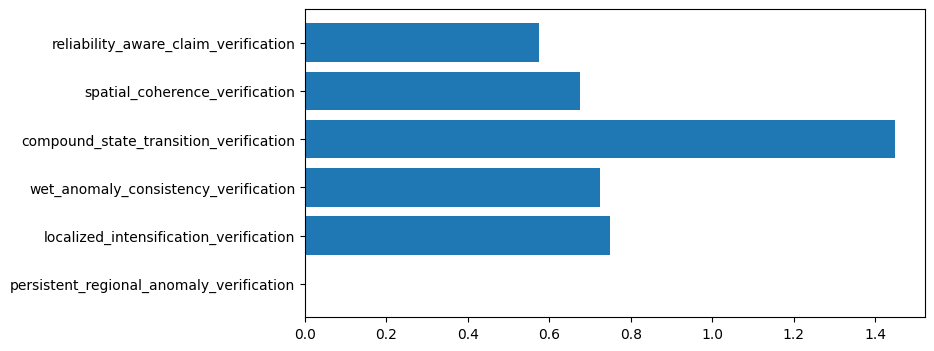

In [76]:
rows=[]

for cat in master.subcategory.unique():

    subset=master[master.subcategory==cat]

    disagreement=(4-subset.ModelsCorrect).mean()

    rows.append({

        "Category":cat,

        "Disagreement":disagreement

    })

df=pd.DataFrame(rows)

display(df)

plt.figure(figsize=(8,4))

plt.barh(df.Category,df.Disagreement)

plt.show()

In [77]:
from scipy.stats import spearmanr

difficulty=[]

improvement=[]

for cat in master.subcategory.unique():

    subset=master[master.subcategory==cat]

    difficulty.append(
        4-subset.ModelsCorrect.mean()
    )

    improvement.append(
        100*(
        subset.ChatGPT_V2_correct.mean()
        -
        subset.ChatGPT_V1_correct.mean()
        )
    )

rho,p=spearmanr(difficulty,improvement)

print(rho,p)

-0.5428571428571429 0.26570262390670546


In [80]:
import json
import pandas as pd

with open("../benchmark/ClimateTwinBench_Hypothesis_V2.json", "r", encoding="utf-8") as f:
    bench = json.load(f)

questions = bench["questions"]

print(len(questions))

240


In [81]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
e:\ClimateTwinIndia\notebooks


In [82]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if "Hypothesis" in file and file.endswith(".json"):
            print(os.path.join(root, file))

..\benchmark\ClimateTwinBench_Hypothesis.json
..\benchmark\ClimateTwinBench_Hypothesis_public.json
..\benchmark\ClimateTwinBench_Hypothesis_publicV2.json
..\benchmark\ClimateTwinBench_Hypothesis_V2.json


In [83]:
import json
import pandas as pd

with open("../benchmark/ClimateTwinBench_Hypothesis_V2.json",
          encoding="utf-8") as f:

    bench=json.load(f)

questions=bench["questions"]

print(len(questions))

240


In [84]:
rows=[]

for q in questions:

    rows.append({

        "id":q["id"],

        "subcategory":q["subcategory"],

        "difficulty":q["difficulty"],

        "answer":q["answer"],

        "question":q["question"]

    })

derive_df=pd.DataFrame(rows)

derive_df.head()

,id,subcategory,difficulty,answer,question
0,HYP-001,persistent_regional_anomaly_verification,medium,C,Hypothesis:\n The 3x3 region centered at (18....
1,HYP-002,persistent_regional_anomaly_verification,medium,A,Hypothesis:\n The 3x3 region centered at (17....
2,HYP-003,persistent_regional_anomaly_verification,medium,B,Hypothesis:\n The 3x3 region centered at (17....
3,HYP-004,persistent_regional_anomaly_verification,medium,C,Hypothesis:\n The 3x3 region centered at (32....
4,HYP-005,persistent_regional_anomaly_verification,medium,C,Hypothesis:\n The 3x3 region centered at (18....


In [85]:
PROMPT = """

IMPORTANT

Before selecting A, B or C you MUST compute every intermediate value required by the protocol.

Return EXACTLY this format.

Derived Values
Metric_1 = ...
Metric_2 = ...
Metric_3 = ...

Decision = A/B/C

Do not explain anything else.

"""

In [86]:
derive_df["Prompt"]=derive_df["question"]+"\n"+PROMPT

In [87]:
derive_df.to_csv(

"../results/intermediate_derivation_prompts.csv",

index=False

)

print("Saved.")

Saved.
